In [282]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [283]:
iris = load_iris()

In [284]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [285]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [286]:
X = iris.data
y = iris.target

print(X.shape)

(150, 4)


In [287]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

df.sample(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
12,4.8,3.0,1.4,0.1,0
0,5.1,3.5,1.4,0.2,0
70,5.9,3.2,4.8,1.8,1
40,5.0,3.5,1.3,0.3,0
123,6.3,2.7,4.9,1.8,2
99,5.7,2.8,4.1,1.3,1
37,4.9,3.6,1.4,0.1,0
49,5.0,3.3,1.4,0.2,0
45,4.8,3.0,1.4,0.3,0
130,7.4,2.8,6.1,1.9,2


# Split the dataset

In [288]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [289]:
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


In [290]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [291]:
y_predict = model.predict(X_test)

print(y_predict)
print(y_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [292]:
table = pd.DataFrame({'Actual': y_test, 'Predicted': y_predict})

table['Actual'] = table['Actual'].map(dict(enumerate(iris.target_names)))
table['Predicted'] = table['Predicted'].map(dict(enumerate(iris.target_names)))

print("Sample Predictions with Actual values: ")
table.sample(10)

Sample Predictions with Actual values: 


,Actual,Predicted
22,setosa,setosa
7,virginica,virginica
4,versicolor,versicolor
26,virginica,virginica
18,versicolor,versicolor
27,virginica,virginica
5,setosa,setosa
6,versicolor,versicolor
10,virginica,virginica
3,versicolor,versicolor


# Evaluation

In [293]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [294]:
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict, average='macro')
rec = recall_score(y_test, y_predict, average='macro')
f1 = f1_score(y_test, y_predict, average='macro')

In [295]:
print(f"Accuracy = {acc:.2f}")
print(f"Precision = {prec:.2f}")
print(f"Recall = {rec:.2f}")
print(f"F1 Score = {f1:.2f}")

Accuracy = 1.00
Precision = 1.00
Recall = 1.00
F1 Score = 1.00


# Confusion Matrix

In [296]:
cm = confusion_matrix(y_test, y_predict)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


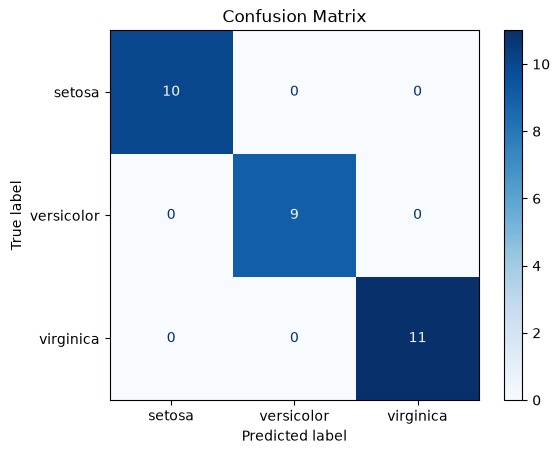

In [297]:
visual = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
visual.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("ConfusionMatrix.png", bbox_inches='tight')

# Decision Tree Model

In [298]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [299]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)  # on max depth 2 it was giving one wrong prediction

In [300]:
tree_model.fit(X_train, y_train)
pred = tree_model.predict(X_test)

[Text(0.375, 0.875, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]\nclass = versicolor'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal length (cm) <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal width (cm) <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.75, 0.375, 'petal width (cm) <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 8\nvalue = [0, 4, 4]\nclass = versicolor'),
 Text(0.875, 0.125, 'gini = 0.056\nsamples = 35\nvalue = [0, 1, 34]\nclass = virginica')]

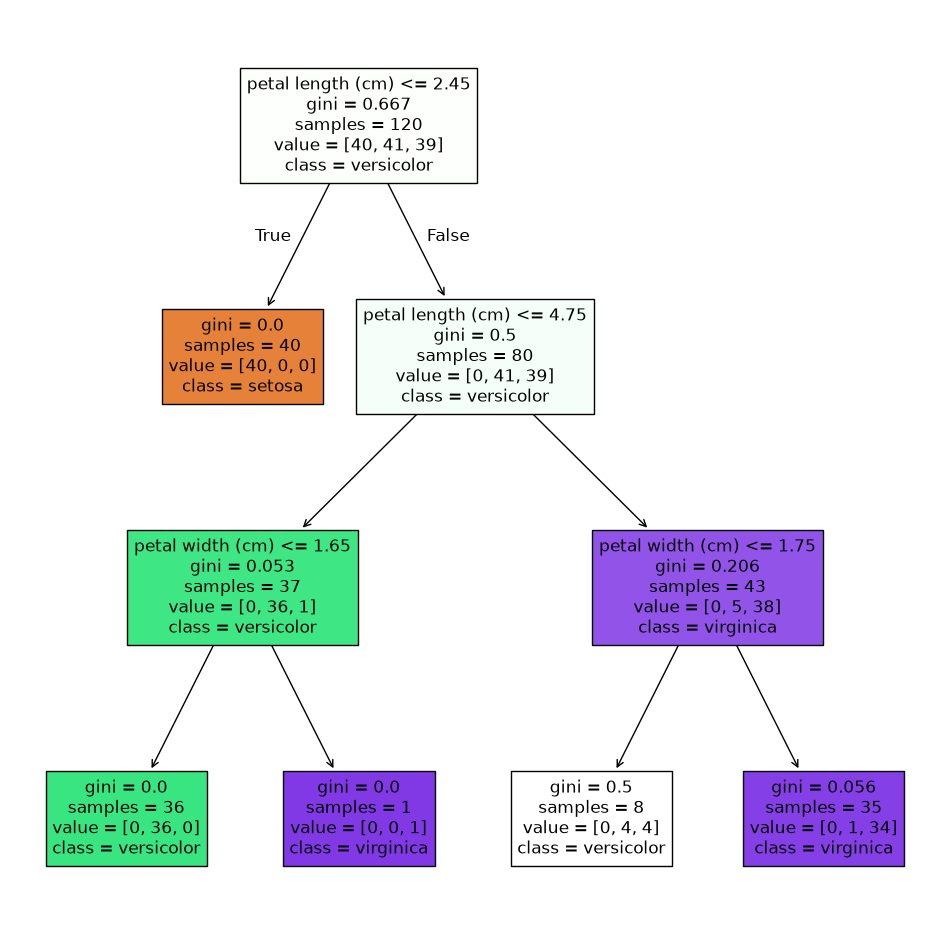

In [301]:
plt.figure(figsize=(12,12))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)

In [302]:
print("Actual:", y_test)
print("Actual:", pred)

Actual: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [303]:
t_acc = accuracy_score(y_test, pred)
t_prec = precision_score(y_test, pred, average='macro')
t_rec = recall_score(y_test, pred, average='macro')
t_f1 = f1_score(y_test, pred, average='macro')

In [304]:
print(f"Accuracy = {t_acc:.2f}")
print(f"Precision = {t_prec:.2f}")
print(f"Recall = {t_rec:.2f}")
print(f"F1 Score = {t_f1:.2f}")

Accuracy = 1.00
Precision = 1.00
Recall = 1.00
F1 Score = 1.00


In [305]:
t_cm = confusion_matrix(y_test, pred)
print(t_cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

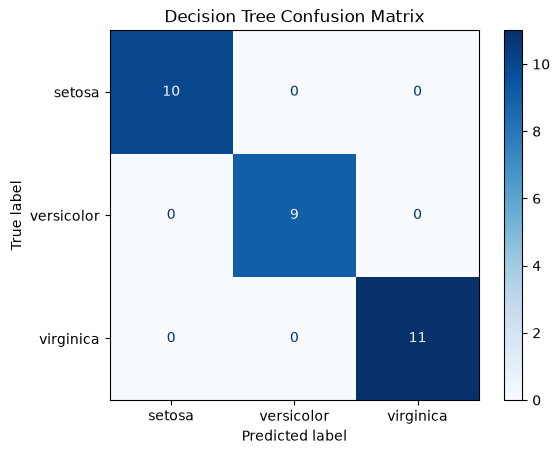

In [306]:
t_visual = ConfusionMatrixDisplay(confusion_matrix=t_cm, display_labels=iris.target_names)
t_visual.plot(cmap='Blues')
plt.title("Decision Tree Confusion Matrix")

In [307]:
print("LogReg train:", model.score(X_train, y_train))
print("LogReg test:", model.score(X_test, y_test))
print("Tree train:", tree_model.score(X_train, y_train))
print("Tree test:", tree_model.score(X_test, y_test))

LogReg train: 0.975
LogReg test: 1.0
Tree train: 0.9583333333333334
Tree test: 1.0


**Observations**
- Both models scored perfectly on the test set; Logistic Regression scored slightly higher on training data (0.975 vs 0.958).
- Test ≥ train accuracy for both, indicating neither model overfits.
- The Decision Tree splits first on petal length (isolating Setosa), then petal width (separating Versicolor/Virginica) — consistent with these being the two most correlated features with species (0.95 and 0.96).
- The tree's one impure node (4 Versicolor vs 4 Virginica) shows where its hard threshold splits struggle with overlapping classes; Logistic Regression's smoother boundary handles this slightly better, reflected in its higher train accuracy.
- Decision Tree is more interpretable — its exact rules are readable from the diagram. Logistic Regression's boundary is smoother but not directly explainable.
- With only 30 test samples, identical 1.0 scores reflect strong performance on this split, not proof of perfect generalization.

**Conclusion:** Both models perform strongly on Iris. Decision Tree offers clearer interpretability; Logistic Regression fit the training data marginally better and may generalize more smoothly on noisier data.